Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

Uploading Dataset


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving job_salary_prediction_dataset.csv to job_salary_prediction_dataset (2).csv


In [ ]:
df = pd.read_csv('job_salary_prediction_dataset.csv')
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


Basic Information


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
None
       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37

Classification (creating target variable)

In [ ]:
df['salary_class'] = pd.qcut(df['salary'], q=3, labels=['Low','Medium','High'])
df.drop('salary', axis=1, inplace=True)

EDA

<function matplotlib.pyplot.show(close=None, block=None)>

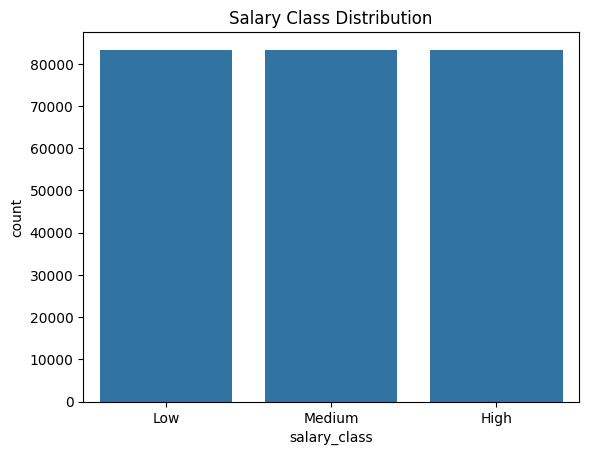

In [ ]:
plt.figure()
sns.countplot(x='salary_class', data=df)
plt.title('Salary Class Distribution')
plt.show

Handling categorical variables

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

Feature Engineering

In [ ]:
x=df.drop('salary_class', axis=1)
y=df['salary_class']

Training test data and split

In [ ]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

Scaling

In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

Model Building

In [ ]:
models={
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}
result={}
for name, model in models.items():
  model.fit(x_train, y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_test, y_pred)
  result[name]=acc
  print(f"{name} Accuracy: {acc}")

Logistic Regression Accuracy: 0.58484
Decision Tree Accuracy: 0.84
Random Forest Accuracy: 0.87774


Model Comparison

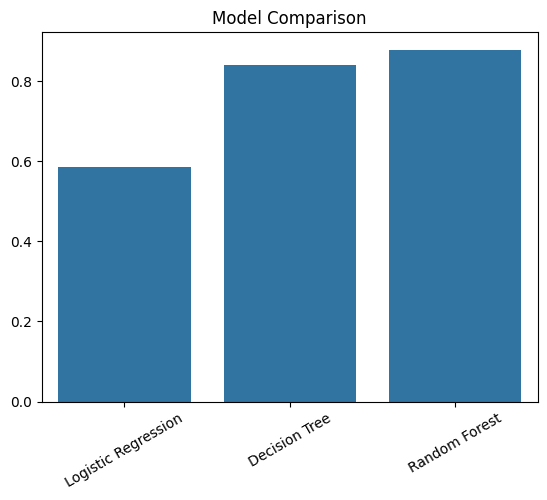

In [ ]:
plt.figure()
sns.barplot(x=list(result.keys()), y=list(result.values()))
plt.title('Model Comparison')
plt.xticks(rotation=30)
plt.show()

Hyperparameter tuning (random forest)

In [ ]:
param_grid={
    'n_estimators': [50,100],
    'max_depth': [None, 10, 20]
}
grid=GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(x_train, y_train)
best_model=grid.best_estimator_

Final Evaluation

In [ ]:
y_pred=best_model.predict(x_test)
print("Final Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Final Model Accuracy: 0.87818
              precision    recall  f1-score   support

        High       0.91      0.91      0.91     16685
         Low       0.92      0.90      0.91     16560
      Medium       0.81      0.83      0.82     16755

    accuracy                           0.88     50000
   macro avg       0.88      0.88      0.88     50000
weighted avg       0.88      0.88      0.88     50000



Confusion Matrix

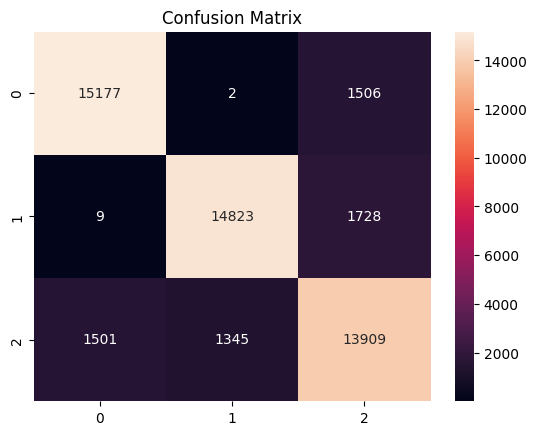

In [ ]:
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

import pickle
pickle.dump(best_model, open('model.pkl', 'wb'))

Streamlit

In [ ]:
!pip install streamlit
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open('model.pkl', 'rb'))

st.title('Salary Classification App')

experience = st.number_input('Experience Years')

if st.button('Predict'):
    prediction = model.predict([[experience]])
    st.write('Predicted Salary Class:', prediction)

2026-04-08 06:47:10.318 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 06:47:10.334 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 06:47:10.341 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 06:47:10.346 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 06:47:10.349 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 06:47:10.356 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 06:47:10.363 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 06:47:10.375 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar